# Notebook 01 — Data Preparation: Parallel Corpus & Setup

**TIN-7: Cross-Lingual Embedding Alignment Analysis**

This notebook loads the FLORES-200 parallel corpus for all 13 target
languages, validates alignment, computes corpus statistics, and
visualizes language metadata. It serves as the data foundation for
all subsequent analysis notebooks.

## What this notebook does

1. Loads FLORES-200 `devtest` split (1,012 parallel sentences) for
   13 languages spanning 5 families and 6 scripts.
2. Displays sample aligned sentences across languages.
3. Computes and visualizes corpus statistics (character lengths,
   word counts) to reveal tokenizer fertility differences.
4. Produces a summary table of language metadata (family, script,
   resource level, FLORES code).

## Prerequisites

```bash
pip install -e ".[all]"
```

In [1]:
# --- Standard library imports ---
import logging
import sys
from pathlib import Path

# --- Third-party imports ---
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# --- Project imports ---
# Ensure the project root is on the Python path.
PROJECT_ROOT = Path("../..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.languages import (
    Language,
    LANGUAGE_FAMILIES,
    SCRIPT_GROUPS,
    RESOURCE_GROUPS,
)
from src.data.flores_loader import (
    load_flores_parallel_corpus,
    get_corpus_statistics,
)

# --- Logging configuration ---
logging.basicConfig(level=logging.INFO, format="%(levelname)s: %(message)s")
logger = logging.getLogger(__name__)

# --- Output directory for figures ---
FIGURES_DIR = PROJECT_ROOT / "analysis" / "results" / "cross_lingual" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Figures dir:  {FIGURES_DIR}")

Project root: /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood
Figures dir:  /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/figures


## 1. Language Metadata Summary

Before loading any data, let's review the 13 languages and their
metadata. This table is the reference for all subsequent analysis.

In [2]:
# Build a DataFrame of all language metadata.
metadata_rows = []
for lang in Language:
    metadata_rows.append({
        "Language": lang.lang_name.title(),
        "ISO Code": lang.iso_code,
        "FLORES Code": lang.flores_code,
        "Script": lang.script,
        "Family": lang.family,
        "Resource Level": lang.resource_level,
    })

metadata_df = pd.DataFrame(metadata_rows)
print("=== Language Metadata ===")
print(metadata_df.to_string(index=False))
print(f"\nTotal languages: {len(metadata_df)}")
print(f"Unique families: {metadata_df['Family'].nunique()}")
print(f"Unique scripts:  {metadata_df['Script'].nunique()}")

=== Language Metadata ===
Language ISO Code FLORES Code     Script        Family Resource Level
   Hindi       hi    hin_Deva Devanagari Indo-European            mid
 English       en    eng_Latn      Latin Indo-European           high
 Bengali       bn    ben_Beng    Bengali Indo-European            mid
   Tamil       ta    tam_Taml      Tamil     Dravidian            mid
 Swahili       sw    swh_Latn      Latin   Niger-Congo            low
 Amharic       am    amh_Ethi      Ge'ez  Afro-Asiatic            low
  Yoruba       yo    yor_Latn      Latin   Niger-Congo            low
  Arabic       ar    arb_Arab     Arabic  Afro-Asiatic           high
 Turkish       tr    tur_Latn      Latin        Turkic            mid
 Persian       fa    pes_Arab     Arabic Indo-European            mid
  German       de    deu_Latn      Latin Indo-European           high
  French       fr    fra_Latn      Latin Indo-European           high
 Spanish       es    spa_Latn      Latin Indo-European          

## 2. Load FLORES+ Parallel Corpus

We load the `devtest` split which contains 1,012 professionally
translated sentences across all 200+ languages. We extract only
our 13 target languages.

In [3]:
# Load the parallel corpus for all 13 languages.
# On first run, this downloads ~300MB from HuggingFace Hub.
corpus = load_flores_parallel_corpus()

# Validate alignment: all languages should have the same count.
counts = {lang: len(sents) for lang, sents in corpus.items()}
print(f"\n=== Corpus Loaded ===")
print(f"Languages: {len(corpus)}")
print(f"Sentences per language: {set(counts.values())}")
print(f"Total sentence-pairs: {sum(counts.values())}")

INFO: Loading FLORES+ 'devtest' split for 13 languages...
INFO:   Loading hindi (hin_Deva)...
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/main/README.md "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/openlanguagedata/flores_plus/openlanguagedata/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://huggingface.co/api/datasets/openlanguagedata/flores_plus/revision/1c079b04e227e9646edd65ae6264339e5db97122 "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=openlanguagedat

Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

INFO: HTTP Request: GET https://huggingface.co/api/datasets/openlanguagedata/flores_plus/tree/1c079b04e227e9646edd65ae6264339e5db97122/devtest?recursive=true&expand=false "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/dataset_infos.json "HTTP/1.1 404 Not Found"
INFO:   Loading english (eng_Latn)...
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/main/README.md "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/openlanguagedata/flores_plus/openlanguagedata/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=openlanguagedata/flores_plus "HTTP/1.1 200 OK"


...

INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/dataset_infos.json "HTTP/1.1 404 Not Found"
INFO:   Loading spanish (spa_Latn)...
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/main/README.md "HTTP/1.1 200 OK"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://s3.amazonaws.com/datasets.huggingface.co/datasets/datasets/openlanguagedata/flores_plus/openlanguagedata/flores_plus.py "HTTP/1.1 404 Not Found"
INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/.huggingface.yaml "HTTP/1.1 404 Not Found"
INFO: HTTP Request: GET https://datasets-server.huggingface.co/info?dataset=openlanguagedata/flores_plus "HTTP/1.1 200 OK"


Resolving data files:   0%|          | 0/225 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/220 [00:00<?, ?it/s]

INFO: HTTP Request: HEAD https://huggingface.co/datasets/openlanguagedata/flores_plus/resolve/1c079b04e227e9646edd65ae6264339e5db97122/dataset_infos.json "HTTP/1.1 404 Not Found"
INFO: Successfully loaded 1012 parallel sentences for 13 languages.



=== Corpus Loaded ===
Languages: 13
Sentences per language: {1012}
Total sentence-pairs: 13156


## 3. Sample Aligned Sentences

Display the first 3 sentences across all languages to visually
confirm alignment (same meaning, different language).

In [4]:
# Display aligned sample sentences.
N_SAMPLES = 3

for i in range(N_SAMPLES):
    print(f"\n{'='*70}")
    print(f"SENTENCE {i+1}")
    print(f"{'='*70}")
    for lang_name in sorted(corpus.keys()):
        iso = next(
            l.iso_code for l in Language if l.lang_name == lang_name
        )
        # Truncate very long sentences for display.
        text = corpus[lang_name][i]
        if len(text) > 120:
            text = text[:117] + "..."
        print(f"  [{iso}] {text}")


SENTENCE 1
  [am] "አሁን የስኳር በሽተኛ ያልነበሩ አሁን ግን የሆኑ የ4-ወር-ዕድሜ ያላቸው አይጦች አሉን፣ አለ። "
  [ar] أضاف قائلاً، "لدينا الآن فئران تبلغ من العمر 4 أشهر التي كانت تعاني في السابق من مرض السكري، ولكنها لم تعد تعاني منه ...
  [bn] """আমাদের এখন ৪-মাস-বয়সী ডায়াবেটিস রোগ ছাড়া ইদুর আছে যেগুলোর আগে ডায়াবেটিস রোগ ছিল,"" তিনি যোগ করলেন।"
  [en] "We now have 4-month-old mice that are non-diabetic that used to be diabetic," he added.
  [fr] « Nous avons à présent des souris de 4 mois qui ne sont pas diabétiques alors qu'elles l'étaient auparavant », a-t-il...
  [de] „Wir haben jetzt 4 Monate alte Mäuse, die Diabetes hatten und jetzt keinen mehr haben“, fügte er hinzu.
  [hi] उन्होंने कहा “कि अब हमारे पास 4 महीने उम्र वाले चूहे हैं जिन्हें मधुमेह नहीं है जो मधुमेह के रोगी थे। ”
  [fa] وی افزود: «اکنون موش‌های 4 ماهه‌ای داریم که دیابت ندارند در حالی که قبلاً دیابت داشتند.»
  [es] «Actualmente, tenemos ratones de cuatro meses de edad que antes solían ser diabéticos y que ya no lo son», agregó.
  [sw] "Sasa tun

## 4. Corpus Statistics

Compute basic statistics for each language. Differences in character
length and word count reveal tokenizer fertility disparities — some
languages require more tokens than others to express the same content.

In [5]:
# Compute statistics.
stats = get_corpus_statistics(corpus)
stats_df = pd.DataFrame(stats).T
stats_df.index.name = "Language"
stats_df = stats_df.round(1)

print("\n=== Corpus Statistics ===")
print(stats_df.to_string())


=== Corpus Statistics ===
          num_sentences  avg_char_length  min_char_length  max_char_length  avg_word_count
Language                                                                                  
hindi            1012.0            129.5             41.0            381.0            25.3
english          1012.0            130.4             35.0            368.0            21.6
bengali          1012.0            127.5             38.0            333.0            19.3
tamil            1012.0            152.3             48.0            404.0            16.6
swahili          1012.0            136.5             37.0            384.0            21.0
amharic          1012.0             86.1             26.0            219.0            17.1
yoruba           1012.0            125.3             27.0            391.0            24.9
arabic           1012.0            114.9             34.0            316.0            19.4
turkish          1012.0            134.2             44.0      

## 5. Visualization: Average Character Length per Language

This bar chart reveals which languages use more characters to
express the same content. Languages with agglutinative morphology
(e.g., Turkish, Tamil) or non-Latin scripts (e.g., Arabic, Hindi)
may show different patterns.

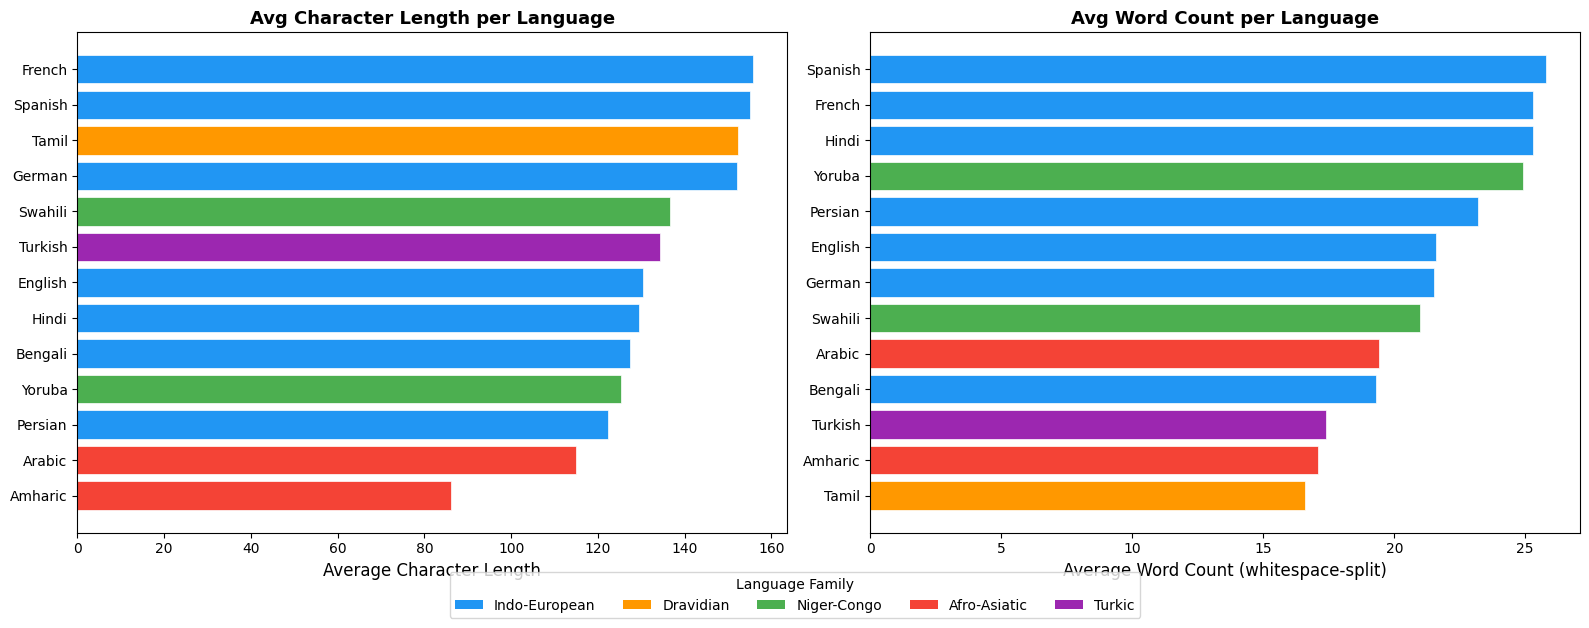

Figure saved to: /teamspace/studios/this_studio/Tiny-Aya-Under-the-hood/analysis/results/cross_lingual/figures/corpus_statistics.png


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart: Average character length ---
sorted_stats = stats_df.sort_values("avg_char_length", ascending=False)

colors = []
family_color_map = {
    "Indo-European": "#2196F3",
    "Dravidian": "#FF9800",
    "Niger-Congo": "#4CAF50",
    "Afro-Asiatic": "#F44336",
    "Turkic": "#9C27B0",
}
for lang_name in sorted_stats.index:
    lang = next(l for l in Language if l.lang_name == lang_name)
    colors.append(family_color_map.get(lang.family, "#757575"))

axes[0].barh(
    sorted_stats.index.str.title(),
    sorted_stats["avg_char_length"],
    color=colors,
    edgecolor="white",
    linewidth=0.5,
)
axes[0].set_xlabel("Average Character Length", fontsize=12)
axes[0].set_title("Avg Character Length per Language", fontsize=13, fontweight="bold")
axes[0].invert_yaxis()

# --- Bar chart: Average word count ---
sorted_words = stats_df.sort_values("avg_word_count", ascending=False)

colors_w = []
for lang_name in sorted_words.index:
    lang = next(l for l in Language if l.lang_name == lang_name)
    colors_w.append(family_color_map.get(lang.family, "#757575"))

axes[1].barh(
    sorted_words.index.str.title(),
    sorted_words["avg_word_count"],
    color=colors_w,
    edgecolor="white",
    linewidth=0.5,
)
axes[1].set_xlabel("Average Word Count (whitespace-split)", fontsize=12)
axes[1].set_title("Avg Word Count per Language", fontsize=13, fontweight="bold")
axes[1].invert_yaxis()

# Add a legend for language families.
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=color, label=family)
    for family, color in family_color_map.items()
]
fig.legend(
    handles=legend_elements,
    loc="lower center",
    ncol=5,
    fontsize=10,
    title="Language Family",
    bbox_to_anchor=(0.5, -0.05),
)

plt.tight_layout()
fig.savefig(FIGURES_DIR / "corpus_statistics.png", bbox_inches="tight")
plt.show()

print("Figure saved to:", FIGURES_DIR / "corpus_statistics.png")

## 6. Language Distribution by Family and Script

Pie charts showing the distribution of our 13 languages across
language families and writing scripts.

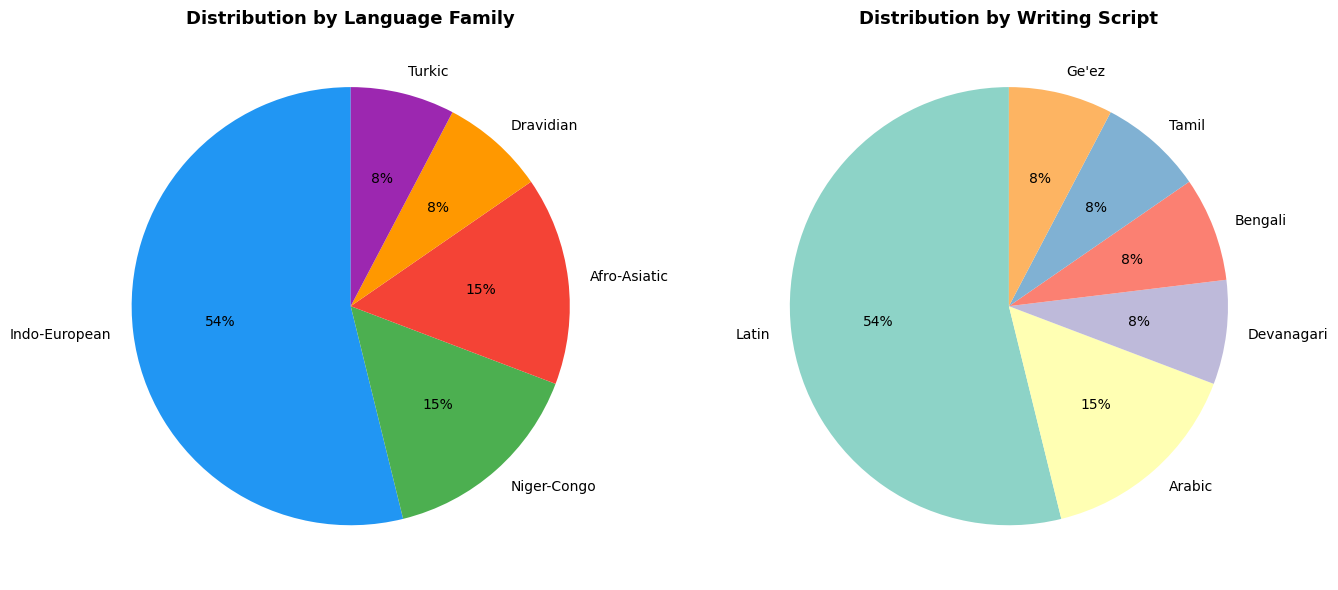

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Family distribution ---
family_counts = metadata_df["Family"].value_counts()
axes[0].pie(
    family_counts.values,
    labels=family_counts.index,
    autopct="%1.0f%%",
    colors=[family_color_map.get(f, "#757575") for f in family_counts.index],
    startangle=90,
)
axes[0].set_title("Distribution by Language Family", fontsize=13, fontweight="bold")

# --- Script distribution ---
script_counts = metadata_df["Script"].value_counts()
script_colors = plt.cm.Set3(range(len(script_counts)))
axes[1].pie(
    script_counts.values,
    labels=script_counts.index,
    autopct="%1.0f%%",
    colors=script_colors,
    startangle=90,
)
axes[1].set_title("Distribution by Writing Script", fontsize=13, fontweight="bold")

plt.tight_layout()
fig.savefig(FIGURES_DIR / "language_distributions.png", bbox_inches="tight")
plt.show()

## 7. Summary

**Key observations from data preparation:**

- All 13 languages loaded successfully with 1,012 aligned sentences each.
- Character length varies significantly across languages due to
  morphological and script differences.
- The language set covers 5 families and 6 scripts, providing good
  diversity for cross-lingual analysis.
- Data is ready for activation extraction in Notebook 02.

In [8]:
print("\n=== Data Preparation Complete ===")
print(f"  Languages: {len(corpus)}")
print(f"  Sentences/language: {len(next(iter(corpus.values())))}")
print(f"  Families: {list(LANGUAGE_FAMILIES.keys())}")
print(f"  Scripts:  {list(SCRIPT_GROUPS.keys())}")
print("\nNext step: Run Notebook 02 to extract layer-wise activations.")


=== Data Preparation Complete ===
  Languages: 13
  Sentences/language: 1012
  Families: ['Indo-European', 'Dravidian', 'Niger-Congo', 'Afro-Asiatic', 'Turkic']
  Scripts:  ['Devanagari', 'Latin', 'Bengali', 'Tamil', "Ge'ez", 'Arabic']

Next step: Run Notebook 02 to extract layer-wise activations.
